# 08 - Analyses complémentaires

J'explore ici les analyses annexes : audit de contamination pHash, présentation des datasets, bootstrap sur les ratios σ du BNN image seule (ablation sans branche clinique), comparaisons d'architectures CNN et test d'incertitude sur des images hors cerveau.

### 1. Imports & seed

In [26]:
import os, random, glob, json, time, pickle
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import (mean_absolute_error, r2_score,
                             balanced_accuracy_score, roc_auc_score)
from scipy.stats import gaussian_kde
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nibabel as nib
import imagehash
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


### 2. Chemins & config

In [27]:
EPIC_ROOT   = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TRAIN_DIR   = os.path.join(EPIC_ROOT, "Train")
TEST_DIR    = os.path.join(EPIC_ROOT, "Test")
IXI_DIR     = os.path.expanduser("~/Documents/Memoire/IXI")
BR35H_ROOT  = "/Users/teodul/Documents/Memoire/Br35H"
BR35H_YES   = os.path.join(BR35H_ROOT, "yes")
BR35H_NO    = os.path.join(BR35H_ROOT, "no")
BR35H_MASK  = os.path.join(BR35H_ROOT, "Br35H-Mask-RCNN")

CNN_CKPT    = "runs_cnn_baseline/best_final.pt"
BNN_CKPT    = "runs_bnn_multimodal/ablation_image_only.pt"
AGE_CKPT    = "runs_brain_age/best.pt"

SAVE_DIR    = "runs_extra"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
MC_PASSES   = 50
CLASSES     = ["glioma", "meningioma", "notumor", "pituitary"]
AGE_MIN, AGE_MAX = 20, 86

ORIG_ROOT      = "/Users/teodul/Documents/Memoire/Brain Tumor MRI Dataset"
ORIG_TRAIN_DIR = os.path.join(ORIG_ROOT, "Train")
ORIG_TEST_DIR  = os.path.join(ORIG_ROOT, "Test")

### 3. Transforms & utilitaires

In [28]:
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

### 4. Audit pHash - contamination

In [56]:
def phash_int(p):
    return int(str(imagehash.phash(Image.open(p).convert("L"), hash_size=8)), 16)

def bits(arr):
    return np.unpackbits(arr.view(np.uint8).reshape(-1, 8), axis=1)

def load_all_paths(root):
    paths = [p for p in glob.glob(os.path.join(root, "**", "*.*"), recursive=True)
             if p.lower().endswith((".jpg", ".jpeg", ".png"))]
    return sorted(set(paths))

In [57]:
print("Calcul des hashes...")
orig_train = load_all_paths(ORIG_TRAIN_DIR)
orig_test  = load_all_paths(ORIG_TEST_DIR)
print(f"Train original : {len(orig_train)} | Test original : {len(orig_test)}")

bits_train = bits(np.array([phash_int(p) for p in orig_train], dtype=np.uint64))
bits_test  = bits(np.array([phash_int(p) for p in orig_test],  dtype=np.uint64))

Calcul des hashes...
Train original : 9650 | Test original : 2414


In [58]:
print("Recherche des doublons train/test...")
min_dists, dup_pairs = [], []

for j, ht in enumerate(bits_test):
    dists = (bits_train ^ ht[None, :]).sum(axis=1)
    d = int(dists.min())
    min_dists.append(d)
    if d <= 4:
        dup_pairs.append((orig_train[int(dists.argmin())], orig_test[j], d))

min_dists = np.array(min_dists)
exact = (min_dists == 0).sum()
near  = (min_dists <= 4).sum()
print(f"\nDoublons exacts (d=0) : {exact}/{len(orig_test)} ({100*exact/len(orig_test):.1f}%)")
print(f"Quasi-doublons (d≤4)  : {near}/{len(orig_test)}  ({100*near/len(orig_test):.1f}%)")

Recherche des doublons train/test...

Doublons exacts (d=0) : 1486/2414 (61.6%)
Quasi-doublons (d≤4)  : 1729/2414  (71.6%)


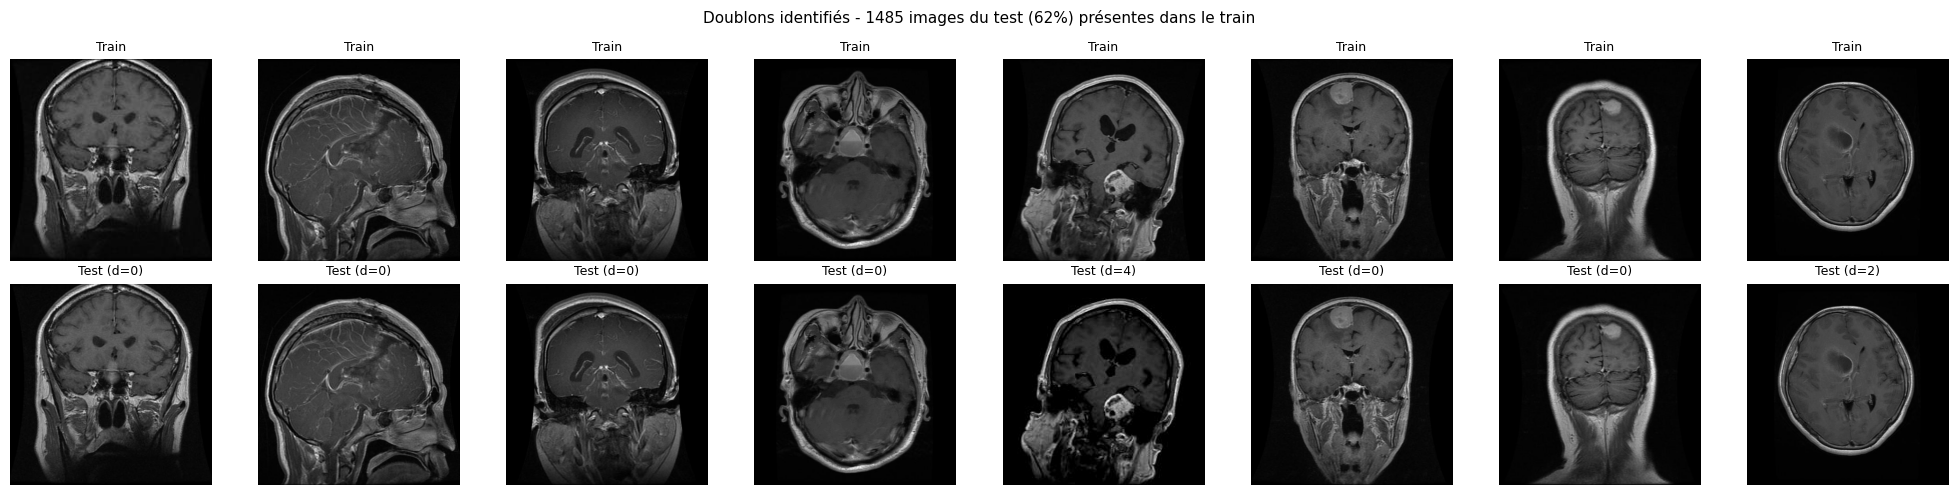

In [32]:
sample = random.sample(dup_pairs, min(8, len(dup_pairs)))
fig, axes = plt.subplots(2, len(sample), figsize=(2.5*len(sample), 5))
for k, (ptr, pte, d) in enumerate(sample):
    axes[0,k].imshow(Image.open(ptr).convert("L"), cmap="gray")
    axes[0,k].set_title("Train", fontsize=9); axes[0,k].axis("off")
    axes[1,k].imshow(Image.open(pte).convert("L"), cmap="gray")
    axes[1,k].set_title(f"Test (d={d})", fontsize=9); axes[1,k].axis("off")
axes[0,0].set_ylabel("Train", fontsize=10)
axes[1,0].set_ylabel("Test", fontsize=10)
plt.suptitle(f"Doublons identifiés - {exact} images du test ({100*exact/len(orig_test):.0f}%) "
             f"présentes dans le train", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/audit_doublons_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

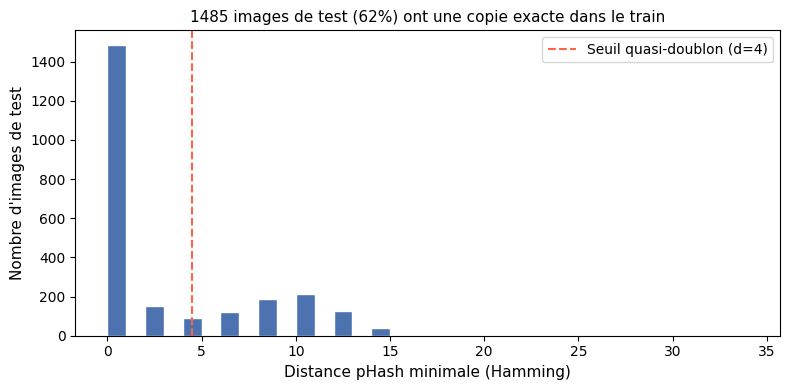

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(min_dists, bins=range(0, 35), color="#4C72B0", edgecolor="white")
ax.axvline(4.5, color="tomato", linestyle="--", lw=1.5, label="Seuil quasi-doublon (d=4)")
ax.set_xlabel("Distance pHash minimale (Hamming)", fontsize=11)
ax.set_ylabel("Nombre d'images de test", fontsize=11)
ax.set_title(f"{exact} images de test ({100*exact/len(orig_test):.0f}%) "
             f"ont une copie exacte dans le train", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/audit_phash_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
clean_train = load_all_paths(TRAIN_DIR)
clean_test  = load_all_paths(TEST_DIR)

rows = [
    ("Dataset original", len(orig_train), len(orig_test), f"{exact} ({100*exact/len(orig_test):.0f}%)"),
    ("Dataset propre",   len(clean_train), len(clean_test), "0 (0%)"),
]
print(f"\n{'':25} {'Train':>8} {'Test':>8} {'Doublons train↔test':>22}")
print("-"*65)
for label, ntr, nte, ndup in rows:
    print(f"{label:25} {ntr:>8} {nte:>8} {ndup:>22}")


                             Train     Test    Doublons train↔test
-----------------------------------------------------------------
Dataset original              9644     2414             1485 (62%)
Dataset propre                4604     1149                 0 (0%)


In [35]:
print("Calcul des hashes (Br35H + train propre)...")
br35h_all = (sorted(glob.glob(os.path.join(BR35H_YES, "*.jpg"))) +
             sorted(glob.glob(os.path.join(BR35H_NO,  "*.jpg"))))
clean_train_paths = load_all_paths(TRAIN_DIR)

print(f"Br35H total     : {len(br35h_all)}")
print(f"Train propre    : {len(clean_train_paths)}")

bits_clean_train = bits(np.array([phash_int(p) for p in clean_train_paths], dtype=np.uint64))
bits_br35h       = bits(np.array([phash_int(p) for p in br35h_all],         dtype=np.uint64))

Calcul des hashes (Br35H + train propre)...
Br35H total     : 3000
Train propre    : 4604


In [36]:
print("Recherche des doublons Br35H ↔ train propre...")
min_dists_br, dup_pairs_br = [], []

for j, hb in enumerate(bits_br35h):
    dists = (bits_clean_train ^ hb[None, :]).sum(axis=1)
    d     = int(dists.min())
    min_dists_br.append(d)
    if d <= 4:
        dup_pairs_br.append((clean_train_paths[int(dists.argmin())], br35h_all[j], d))

min_dists_br = np.array(min_dists_br)
exact_br = (min_dists_br == 0).sum()
near_br  = (min_dists_br <= 4).sum()

print(f"\nDoublons exacts (d=0) : {exact_br}/{len(br35h_all)} ({100*exact_br/len(br35h_all):.1f}%)")
print(f"Quasi-doublons (d≤4)  : {near_br}/{len(br35h_all)}  ({100*near_br/len(br35h_all):.1f}%)")

# Séparation yes / no
yes_total = len(sorted(glob.glob(os.path.join(BR35H_YES, "*.jpg"))))
no_total  = len(br35h_all) - yes_total
dup_yes   = sum(1 for _, p, _ in dup_pairs_br if BR35H_YES in p)
dup_no    = sum(1 for _, p, _ in dup_pairs_br if BR35H_NO  in p)
print(f"\n  Br35H yes (tumeur)     : {dup_yes}/{yes_total} doublons ({100*dup_yes/yes_total:.1f}%)")
print(f"  Br35H no  (pas tumeur) : {dup_no}/{no_total}  doublons ({100*dup_no/no_total:.1f}%)")

Recherche des doublons Br35H ↔ train propre...

Doublons exacts (d=0) : 666/3000 (22.2%)
Quasi-doublons (d≤4)  : 1145/3000  (38.2%)

  Br35H yes (tumeur)     : 102/1500 doublons (6.8%)
  Br35H no  (pas tumeur) : 1043/1500  doublons (69.5%)


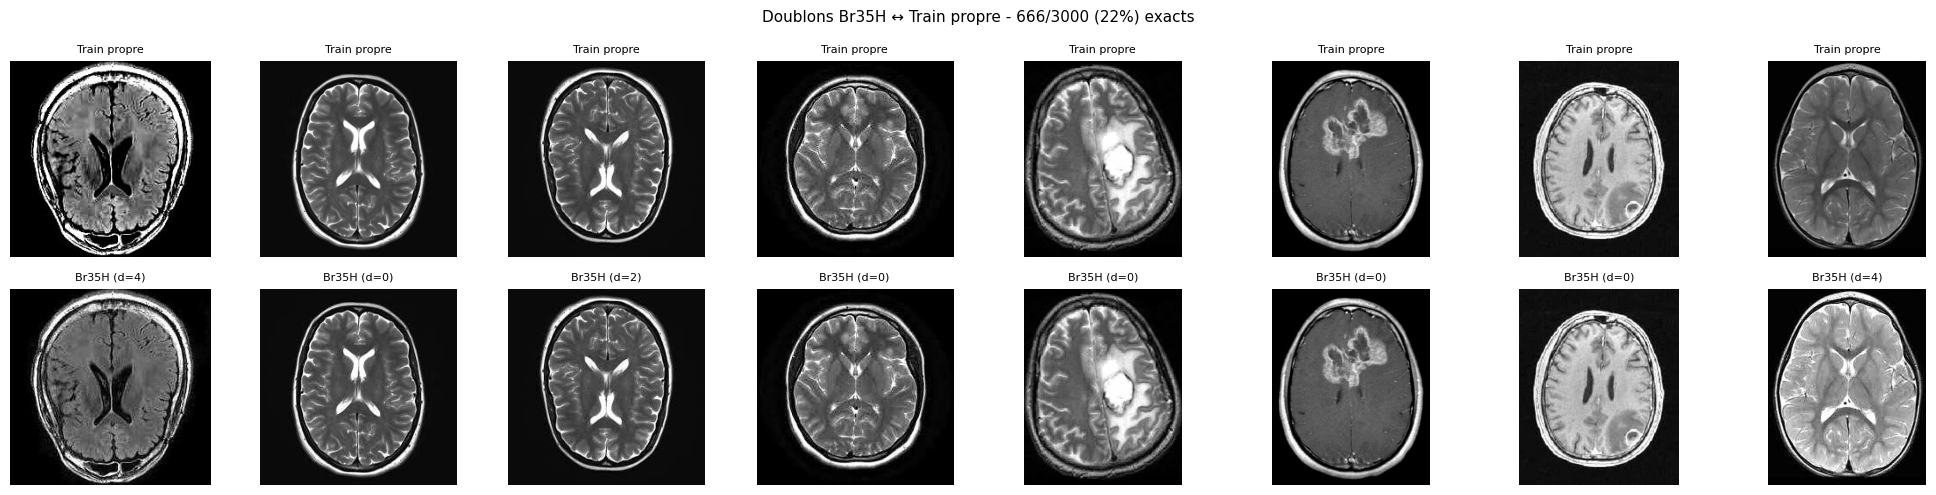

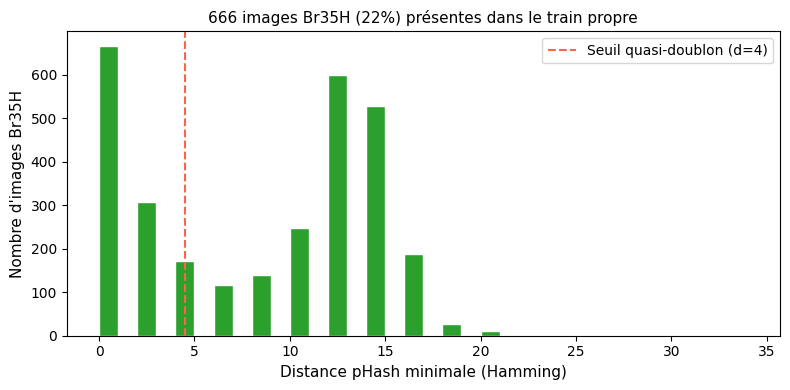

In [37]:
fig, axes_grid = plt.subplots(2, 8, figsize=(20, 5))
sample_br = random.sample(dup_pairs_br, min(8, len(dup_pairs_br)))
for k, (ptr, pbr, d) in enumerate(sample_br):
    axes_grid[0, k].imshow(Image.open(ptr).convert("L"), cmap="gray")
    axes_grid[0, k].set_title("Train propre", fontsize=8); axes_grid[0, k].axis("off")
    axes_grid[1, k].imshow(Image.open(pbr).convert("L"), cmap="gray")
    axes_grid[1, k].set_title(f"Br35H (d={d})", fontsize=8); axes_grid[1, k].axis("off")
plt.suptitle(f"Doublons Br35H ↔ Train propre - {exact_br}/{len(br35h_all)} "
             f"({100*exact_br/len(br35h_all):.0f}%) exacts", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/audit_doublons_br35h.png", dpi=150, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(min_dists_br, bins=range(0, 35), color="#2ca02c", edgecolor="white")
ax2.axvline(4.5, color="tomato", linestyle="--", lw=1.5, label="Seuil quasi-doublon (d=4)")
ax2.set_xlabel("Distance pHash minimale (Hamming)", fontsize=11)
ax2.set_ylabel("Nombre d'images Br35H", fontsize=11)
ax2.set_title(f"{exact_br} images Br35H ({100*exact_br/len(br35h_all):.0f}%) "
              f"présentes dans le train propre", fontsize=11)
ax2.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/audit_phash_br35h.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Mendeley BT-MRI - exemples par classe

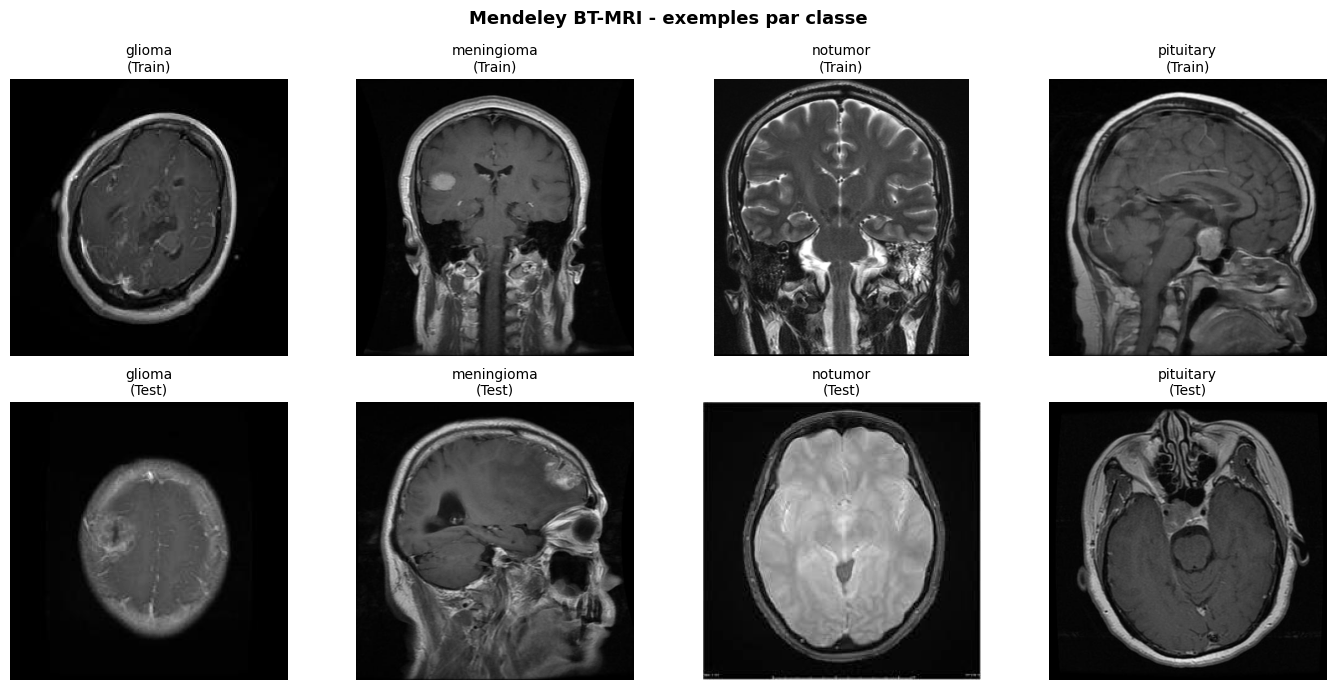

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, cls in enumerate(CLASSES):
    for row, split_dir in enumerate([TRAIN_DIR, TEST_DIR]):
        paths = glob.glob(os.path.join(split_dir, cls, "*.jpg"))
        if not paths:
            paths = glob.glob(os.path.join(split_dir, cls, "*.png"))
        path = random.choice(paths)
        img = Image.open(path).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{cls}\n({'Train' if row==0 else 'Test'})", fontsize=10)
        axes[row, col].axis("off")
plt.suptitle("Mendeley BT-MRI - exemples par classe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_epic_examples.png", dpi=150)
plt.show()

### 6. Mendeley BT-MRI - distribution des classes

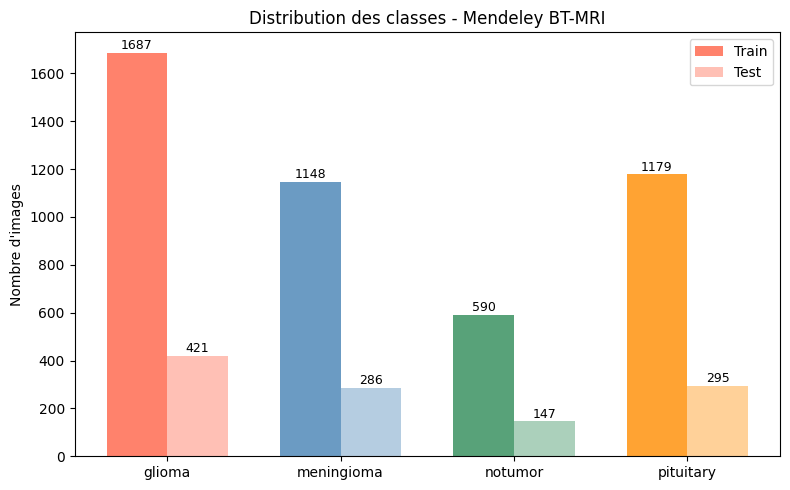

Total : 5753 images
  glioma       train=1687  test=421
  meningioma   train=1148  test=286
  notumor      train=590  test=147
  pituitary    train=1179  test=295


In [39]:
counts_train = {cls: sum(len(glob.glob(os.path.join(TRAIN_DIR, cls, f"*.{ext}"))) for ext in ["jpg", "jpeg", "png"]) for cls in CLASSES}
counts_test  = {cls: sum(len(glob.glob(os.path.join(TEST_DIR,  cls, f"*.{ext}"))) for ext in ["jpg", "jpeg", "png"]) for cls in CLASSES}

x = np.arange(len(CLASSES))
width = 0.35
colors = ["tomato", "steelblue", "seagreen", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, counts_train.values(), width, label="Train", color=colors, alpha=0.8)
bars2 = ax.bar(x + width/2, counts_test.values(),  width, label="Test",  color=colors, alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes - Mendeley BT-MRI")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_epic_distribution.png", dpi=150)
plt.show()

total = sum(counts_train.values()) + sum(counts_test.values())
print(f"Total : {total} images")
for cls in CLASSES:
    print(f"  {cls:12s} train={counts_train[cls]}  test={counts_test[cls]}")

### 7. IXI - distribution des âges

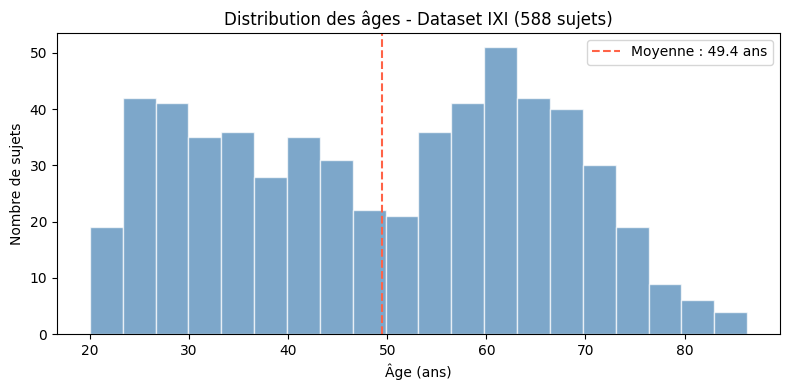

Sujets : 588
Âge min : 20.0  max : 86.3  mean : 49.4


In [40]:
import pandas as pd

ixi_csv = os.path.join(IXI_DIR, "IXI.xls")
df = pd.read_excel(ixi_csv)
df = df[df["AGE"].notna()]
ages = df["AGE"].values

import re
available_ids = set()
for p in glob.glob(os.path.join(IXI_DIR, "**", "*.nii.gz"), recursive=True):
    m = re.match(r'IXI(\d+)', os.path.basename(p))
    if m:
        available_ids.add(int(m.group(1)))

df = df[df["IXI_ID"].isin(available_ids)]
ages = df["AGE"].values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=20, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(ages.mean(), color="tomato", linestyle="--", label=f"Moyenne : {ages.mean():.1f} ans")
ax.set_xlabel("Âge (ans)")
ax.set_ylabel("Nombre de sujets")
ax.set_title(f"Distribution des âges - Dataset IXI ({len(ages)} sujets)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_ixi_ages.png", dpi=150)
plt.show()

print(f"Sujets : {len(ages)}")
print(f"Âge min : {ages.min():.1f}  max : {ages.max():.1f}  mean : {ages.mean():.1f}")

### 8. IXI - exemples de coupes 2D extraites

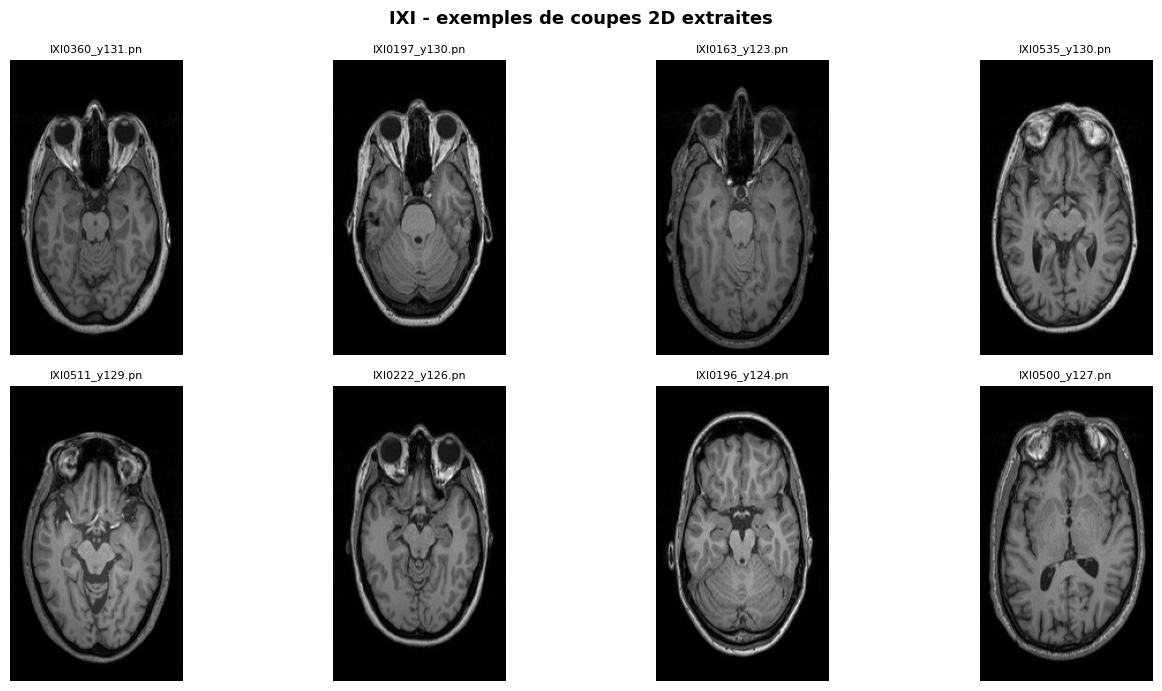

In [41]:
slices_dir = "runs_brain_age/slices_2d"
all_slices = glob.glob(os.path.join(slices_dir, "*.png"))
if not all_slices:
    all_slices = glob.glob(os.path.join(slices_dir, "*.jpg"))

sample_slices = random.sample(all_slices, min(8, len(all_slices)))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, path in zip(axes.flatten(), sample_slices):
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(os.path.basename(path)[:15], fontsize=8)
    ax.axis("off")
plt.suptitle("IXI - exemples de coupes 2D extraites", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_ixi_examples.png", dpi=150)
plt.show()

### 9. Br35H - exemples yes / no et masque de segmentation

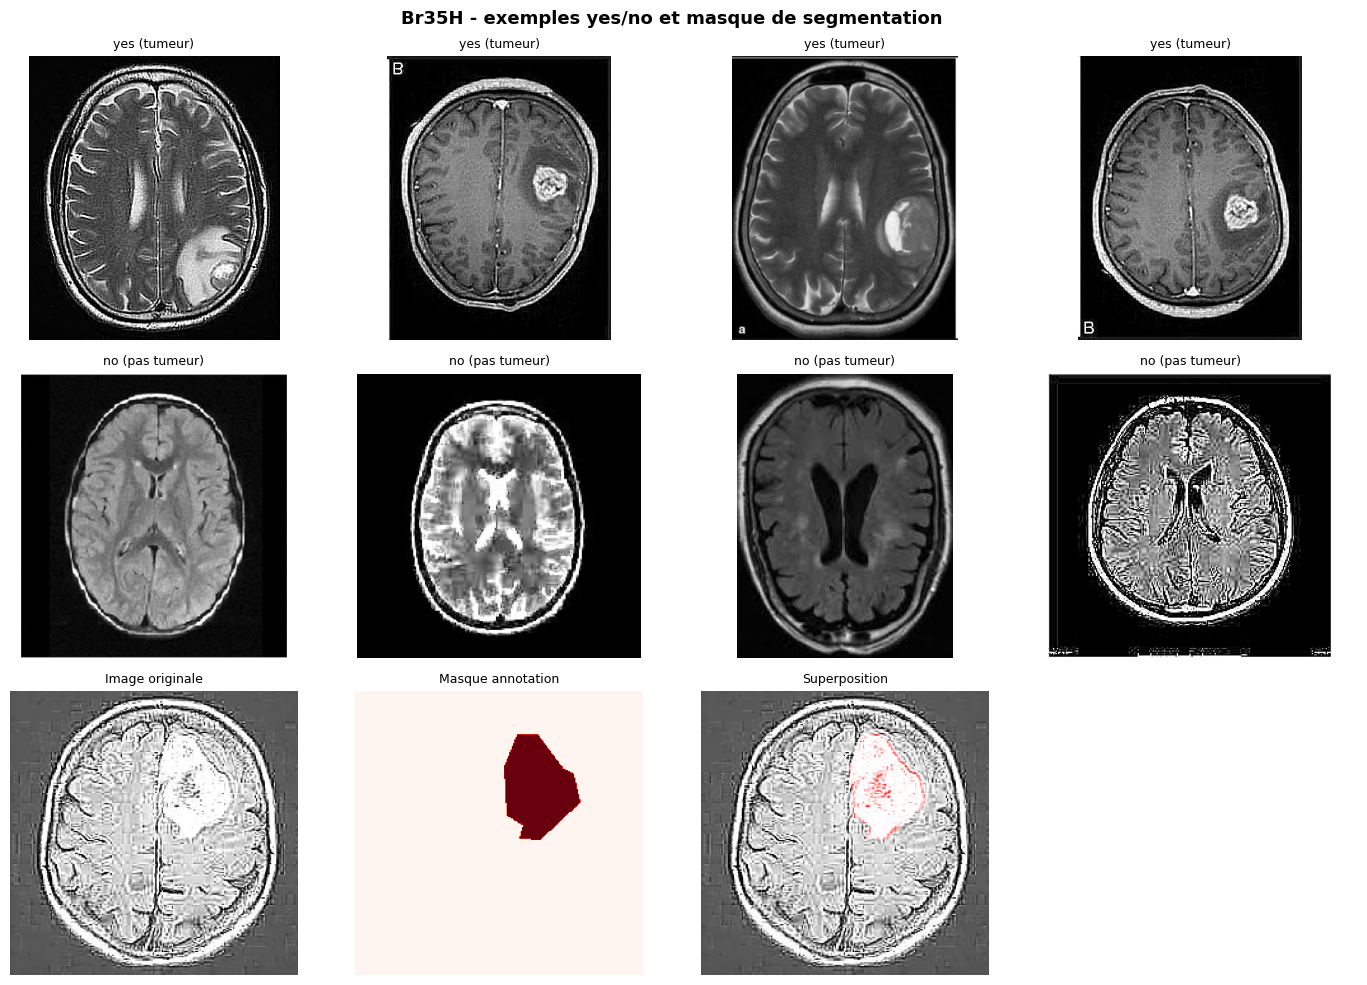

In [42]:
yes_paths = random.sample(glob.glob(os.path.join(BR35H_YES, "*.jpg")), 4)
no_paths  = random.sample(glob.glob(os.path.join(BR35H_NO,  "*.jpg")), 4)

with open(os.path.join(BR35H_MASK, "annotations_all.json")) as f:
    annot = json.load(f)

if "_via_img_metadata" in annot:
    annot = annot["_via_img_metadata"]

annotated = [(k, v) for k, v in annot.items()
             if v.get("regions") and len(v["regions"]) > 0]
key, entry = random.choice(annotated)
img_path_mask = os.path.join(BR35H_MASK, "TRAIN", entry["filename"])
if not os.path.exists(img_path_mask):
    img_path_mask = os.path.join(BR35H_YES, entry["filename"])

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col, p in enumerate(yes_paths):
    axes[0, col].imshow(Image.open(p).convert("L"), cmap="gray")
    axes[0, col].set_title("yes (tumeur)", fontsize=9)
    axes[0, col].axis("off")

for col, p in enumerate(no_paths):
    axes[1, col].imshow(Image.open(p).convert("L"), cmap="gray")
    axes[1, col].set_title("no (pas tumeur)", fontsize=9)
    axes[1, col].axis("off")

if os.path.exists(img_path_mask):
    img_orig = np.array(Image.open(img_path_mask).convert("L"))
    H, W = img_orig.shape
    mask = np.zeros((H, W), dtype=np.uint8)
    import cv2
    for region in entry["regions"]:
        shape = region.get("shape_attributes", region)
        xs = shape.get("all_points_x", [])
        ys = shape.get("all_points_y", [])
        if len(xs) >= 3:
            pts = np.array(list(zip(xs, ys)), dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)
    axes[2, 0].imshow(img_orig, cmap="gray")
    axes[2, 0].set_title("Image originale", fontsize=9)
    axes[2, 0].axis("off")
    axes[2, 1].imshow(mask, cmap="Reds")
    axes[2, 1].set_title("Masque annotation", fontsize=9)
    axes[2, 1].axis("off")
    overlay = np.stack([img_orig]*3, axis=-1).astype(float)
    overlay[mask == 1, 0] = 255
    axes[2, 2].imshow(overlay.astype(np.uint8))
    axes[2, 2].set_title("Superposition", fontsize=9)
    axes[2, 2].axis("off")
axes[2, 3].axis("off")

plt.suptitle("Br35H - exemples yes/no et masque de segmentation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_br35h_examples.png", dpi=150)
plt.show()

### 10. Br35H - distribution des classes

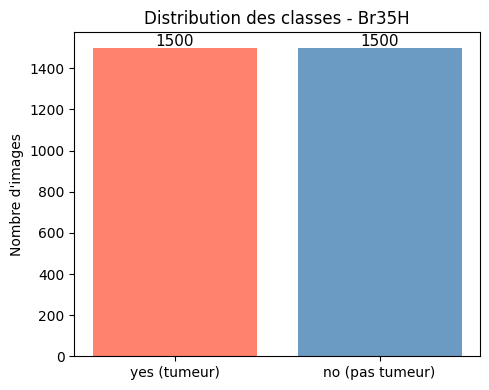

Total : 3000 images  (yes=1500, no=1500)


In [43]:
n_yes = len(glob.glob(os.path.join(BR35H_YES, "*.jpg")))
n_no  = len(glob.glob(os.path.join(BR35H_NO,  "*.jpg")))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["yes (tumeur)", "no (pas tumeur)"], [n_yes, n_no],
       color=["tomato", "steelblue"], alpha=0.8)
for i, v in enumerate([n_yes, n_no]):
    ax.text(i, v + 10, str(v), ha="center", fontsize=11)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes - Br35H")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_br35h_distribution.png", dpi=150)
plt.show()
print(f"Total : {n_yes + n_no} images  (yes={n_yes}, no={n_no})")

### 11. Bootstrap sur les ratios σ par classe

Je charge le BNN image seule (ablation, `ablation_image_only.pt`, sans branche clinique) et j'estime par bootstrap la stabilité du ratio σ incorrect / σ correct pour chaque classe.

In [44]:
class BNNImageOnly(nn.Module):
    def __init__(self, num_classes=4, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )
    def forward(self, img):
        return self.bnn_head(self.cnn(img))

model_bnn = BNNImageOnly().to(device)
ckpt = torch.load(BNN_CKPT, map_location=device, weights_only=False)
model_bnn.load_state_dict(ckpt["model_state"])
model_bnn.eval()
print("BNN chargé")

BNN chargé


In [45]:
all_paths, all_labels_list = [], []
for idx, cls in enumerate(CLASSES):
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    all_paths.extend(paths)
    all_labels_list.extend([idx] * len(paths))

all_labels_arr = np.array(all_labels_list)
all_sigmas_arr, all_preds_arr = [], []

model_bnn.eval()
with torch.no_grad():
    for p in all_paths:
        img_t  = load_image(p)
        passes = torch.stack([
            torch.softmax(model_bnn(img_t), dim=1)
            for _ in range(MC_PASSES)
        ])
        mean_p = passes.mean(0).cpu().numpy()[0]
        std_p  = passes.std(0).cpu().numpy()[0]
        all_preds_arr.append(mean_p.argmax())
        all_sigmas_arr.append(std_p[mean_p.argmax()])

all_preds_arr  = np.array(all_preds_arr)
all_sigmas_arr = np.array(all_sigmas_arr)
print(f"Inférence terminée sur {len(all_paths)} images")

Inférence terminée sur 1149 images


In [46]:
N_BOOTSTRAP = 1000
SAMPLE_FRAC = 0.25
n_total = len(all_paths)
n_sample = int(n_total * SAMPLE_FRAC)

bootstrap_ratios = {cls: [] for cls in CLASSES}

# tirage avec remise sur l'ensemble test pour estimer la variabilité du ratio
for _ in range(N_BOOTSTRAP):
    idx = np.random.choice(n_total, n_sample, replace=True)
    labels_b = all_labels_arr[idx]
    preds_b  = all_preds_arr[idx]
    sigmas_b = all_sigmas_arr[idx]

    for i, cls in enumerate(CLASSES):
        mask_cls   = (labels_b == i)
        correct    = mask_cls & (preds_b == labels_b)
        incorrect  = mask_cls & (preds_b != labels_b)
        if incorrect.sum() > 0 and correct.sum() > 0:
            ratio = sigmas_b[incorrect].mean() / sigmas_b[correct].mean()
            bootstrap_ratios[cls].append(ratio)

print("Bootstrap terminé")
for cls in CLASSES:
    r = np.array(bootstrap_ratios[cls])
    if len(r) > 0:
        print(f"  {cls:12s}  médiane={np.median(r):.2f}  IC95=[{np.percentile(r,2.5):.2f}, {np.percentile(r,97.5):.2f}]  n={len(r)}")

Bootstrap terminé
  glioma        médiane=4.07  IC95=[0.88, 6.87]  n=977
  meningioma    médiane=3.16  IC95=[1.39, 5.33]  n=985
  notumor       médiane=5.44  IC95=[3.84, 7.96]  n=216
  pituitary     médiane=3.73  IC95=[2.94, 5.01]  n=847


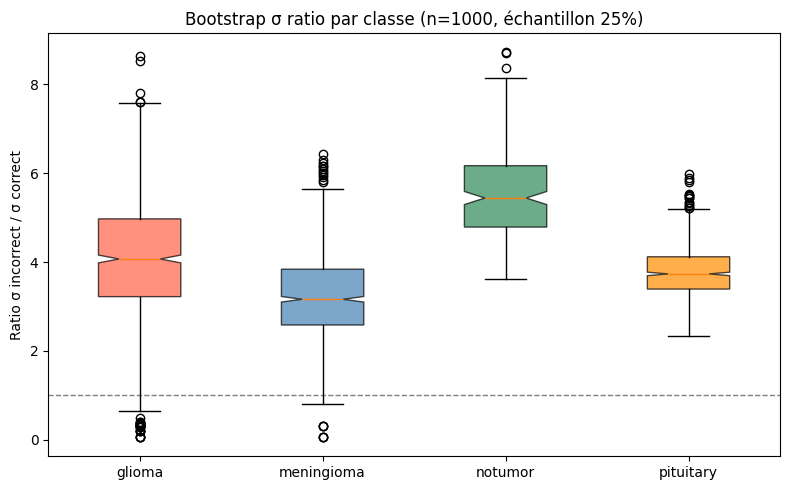

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [bootstrap_ratios[cls] for cls in CLASSES]
colors = ["tomato", "steelblue", "seagreen", "darkorange"]

bp = ax.boxplot(data_plot, patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(CLASSES)
ax.set_ylabel("Ratio σ incorrect / σ correct")
ax.set_title(f"Bootstrap σ ratio par classe (n={N_BOOTSTRAP}, échantillon {int(SAMPLE_FRAC*100)}%)")
ax.axhline(1, color="black", linestyle="--", lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/bootstrap_sigma_ratio.png", dpi=150)
plt.show()

### 12. Comparaison ResNet18 / ResNet34 / ResNet50

In [48]:
from torch.utils.data import WeightedRandomSampler
import re

val_tf_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_full = datasets.ImageFolder(TRAIN_DIR, transform=val_tf_resnet)

def get_patient_id(filepath):
    fname = os.path.basename(filepath)
    for pattern in [r'^(Tr|Te)-\w+_\d+', r'^[A-Z]_\d+', r'^(\w+_\d+)_\d+$', r'^(.+)_\d+\.\w+$']:
        m = re.match(pattern, fname)
        if m:
            return m.group(0)
    return fname.rsplit("_", 1)[0]

subject_ids = list(set([get_patient_id(s[0]) for s in train_full.samples]))
random.shuffle(subject_ids)
val_ids = set(subject_ids[:int(0.15 * len(subject_ids))])

train_idx = [i for i, s in enumerate(train_full.samples) if get_patient_id(s[0]) not in val_ids]
val_idx   = [i for i, s in enumerate(train_full.samples) if get_patient_id(s[0]) in val_ids]

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(datasets.ImageFolder(TRAIN_DIR, transform=val_tf_resnet), val_idx)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=val_tf_resnet)

counts = np.bincount([train_full.samples[i][1] for i in train_idx])
weights = 1.0 / counts
sample_weights = torch.tensor([weights[train_full.samples[i][1]] for i in train_idx], dtype=torch.double)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader_r = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader_r   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader_r  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 3916  Val: 690  Test: 1149


In [49]:
def train_resnet(arch_name, epochs=10, lr=1e-4):
    if arch_name == "resnet18":
        m = models.resnet18(weights="IMAGENET1K_V1")
        in_f = 512
    elif arch_name == "resnet34":
        m = models.resnet34(weights="IMAGENET1K_V1")
        in_f = 512
    elif arch_name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        in_f = 2048

    m.fc = nn.Sequential(nn.Linear(in_f, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, 4))
    m = m.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(m.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_auc, best_state = -1, None
    for epoch in range(1, epochs + 1):
        m.train()
        for x, y in train_loader_r:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            nn.CrossEntropyLoss()(m(x), y).backward()
            optimizer.step()
        scheduler.step()

        m.eval()
        all_y, all_probs = [], []
        with torch.no_grad():
            for x, y in val_loader_r:
                probs = torch.softmax(m(x.to(device)), dim=1).cpu().numpy()
                all_y.extend(y.numpy()); all_probs.extend(probs)
        auc = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        print(f"  {arch_name} epoch {epoch:02d} val_auc={auc:.4f}")

    m.load_state_dict(best_state)
    m.eval()
    all_y, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for x, y in test_loader_r:
            probs = torch.softmax(m(x.to(device)), dim=1).cpu().numpy()
            all_y.extend(y.numpy()); all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1))
    auc  = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
    bacc = balanced_accuracy_score(all_y, all_preds)
    return {"arch": arch_name, "auc": auc, "bal_acc": bacc}

In [50]:
resnet_results = []
for arch in ["resnet18", "resnet34", "resnet50"]:
    print(f"\n=== {arch} ===")
    res = train_resnet(arch, epochs=10)
    resnet_results.append(res)
    print(f"  TEST  AUC={res['auc']:.4f}  BalAcc={res['bal_acc']:.4f}")

print("\n" + "="*45)
print(f"{'Architecture':<15} {'AUC':>8} {'BalAcc':>10}")
print("-"*45)
for r in resnet_results:
    print(f"{r['arch']:<15} {r['auc']:>8.4f} {r['bal_acc']:>10.4f}")


=== resnet18 ===
  resnet18 epoch 01 val_auc=0.9904
  resnet18 epoch 02 val_auc=0.9952
  resnet18 epoch 03 val_auc=0.9987
  resnet18 epoch 04 val_auc=0.9987
  resnet18 epoch 05 val_auc=0.9975
  resnet18 epoch 06 val_auc=0.9991
  resnet18 epoch 07 val_auc=0.9994
  resnet18 epoch 08 val_auc=0.9991
  resnet18 epoch 09 val_auc=0.9992
  resnet18 epoch 10 val_auc=0.9995
  TEST  AUC=0.9984  BalAcc=0.9777

=== resnet34 ===
  resnet34 epoch 01 val_auc=0.9882
  resnet34 epoch 02 val_auc=0.9954
  resnet34 epoch 03 val_auc=0.9947
  resnet34 epoch 04 val_auc=0.9979
  resnet34 epoch 05 val_auc=0.9970
  resnet34 epoch 06 val_auc=0.9992
  resnet34 epoch 07 val_auc=0.9993
  resnet34 epoch 08 val_auc=0.9987
  resnet34 epoch 09 val_auc=0.9984
  resnet34 epoch 10 val_auc=0.9990
  TEST  AUC=0.9986  BalAcc=0.9853

=== resnet50 ===
  resnet50 epoch 01 val_auc=0.9913
  resnet50 epoch 02 val_auc=0.9940
  resnet50 epoch 03 val_auc=0.9948
  resnet50 epoch 04 val_auc=0.9960
  resnet50 epoch 05 val_auc=0.9989
  r

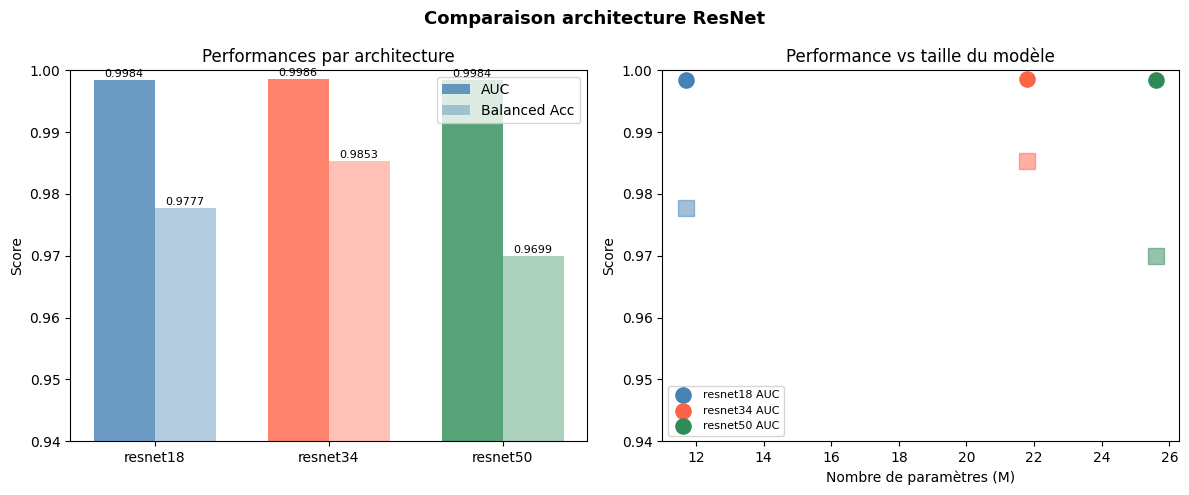

In [51]:
archs   = [r["arch"] for r in resnet_results]
aucs    = [r["auc"] for r in resnet_results]
baccs   = [r["bal_acc"] for r in resnet_results]
params  = {"resnet18": 11.7, "resnet34": 21.8, "resnet50": 25.6}

x = np.arange(len(archs))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(x - width/2, aucs,  width, color=["steelblue", "tomato", "seagreen"], alpha=0.8, label="AUC")
bars2 = axes[0].bar(x + width/2, baccs, width, color=["steelblue", "tomato", "seagreen"], alpha=0.4, label="Balanced Acc")
axes[0].set_xticks(x)
axes[0].set_xticklabels(archs)
axes[0].set_ylim(0.94, 1.0)
axes[0].set_ylabel("Score")
axes[0].set_title("Performances par architecture")
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=8)

n_params = [params[a] for a in archs]
colors   = ["steelblue", "tomato", "seagreen"]
for i, (arch, auc, bacc, n) in enumerate(zip(archs, aucs, baccs, n_params)):
    axes[1].scatter(n, auc,  color=colors[i], s=120, marker="o", label=f"{arch} AUC")
    axes[1].scatter(n, bacc, color=colors[i], s=120, marker="s", alpha=0.5)
axes[1].set_xlabel("Nombre de paramètres (M)")
axes[1].set_ylabel("Score")
axes[1].set_title("Performance vs taille du modèle")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.94, 1.0)

plt.suptitle("Comparaison architecture ResNet", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ablation_resnet.png", dpi=150)
plt.show()

### 13. Comparaison learning rate


=== LR = 1e-05 ===
  resnet18 epoch 01 val_auc=0.9416
  resnet18 epoch 02 val_auc=0.9639
  resnet18 epoch 03 val_auc=0.9780
  resnet18 epoch 04 val_auc=0.9860
  resnet18 epoch 05 val_auc=0.9907
  resnet18 epoch 06 val_auc=0.9916
  resnet18 epoch 07 val_auc=0.9931
  resnet18 epoch 08 val_auc=0.9945
  resnet18 epoch 09 val_auc=0.9946
  resnet18 epoch 10 val_auc=0.9953
  TEST  AUC=0.9922  BalAcc=0.9464

=== LR = 5e-05 ===
  resnet18 epoch 01 val_auc=0.9890
  resnet18 epoch 02 val_auc=0.9958
  resnet18 epoch 03 val_auc=0.9984
  resnet18 epoch 04 val_auc=0.9977
  resnet18 epoch 05 val_auc=0.9973
  resnet18 epoch 06 val_auc=0.9978
  resnet18 epoch 07 val_auc=0.9982
  resnet18 epoch 08 val_auc=0.9985
  resnet18 epoch 09 val_auc=0.9986
  resnet18 epoch 10 val_auc=0.9988
  TEST  AUC=0.9971  BalAcc=0.9673

=== LR = 0.0001 ===
  resnet18 epoch 01 val_auc=0.9855
  resnet18 epoch 02 val_auc=0.9960
  resnet18 epoch 03 val_auc=0.9949
  resnet18 epoch 04 val_auc=0.9970
  resnet18 epoch 05 val_auc=0.9

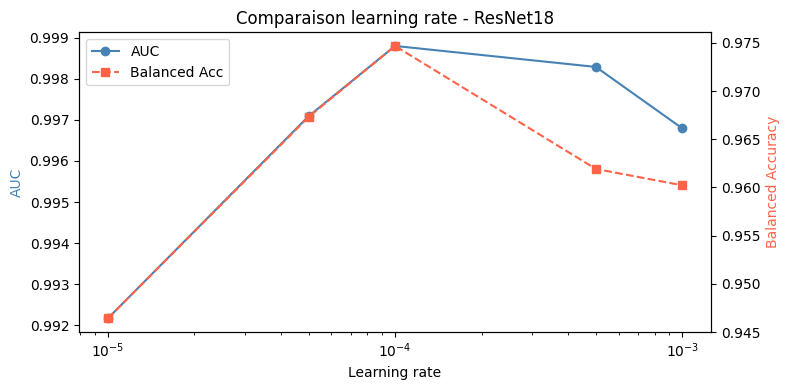

In [55]:
lr_results = []
for lr in [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]:
    print(f"\n=== LR = {lr} ===")
    res = train_resnet("resnet18", epochs=10, lr=lr)
    res["lr"] = lr
    lr_results.append(res)
    print(f"  TEST  AUC={res['auc']:.4f}  BalAcc={res['bal_acc']:.4f}")

lrs   = [r["lr"] for r in lr_results]
aucs  = [r["auc"] for r in lr_results]
baccs = [r["bal_acc"] for r in lr_results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.semilogx(lrs, aucs,  "o-", color="steelblue", label="AUC")
ax2.semilogx(lrs, baccs, "s--", color="tomato",   label="Balanced Acc")
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("AUC", color="steelblue")
ax2.set_ylabel("Balanced Accuracy", color="tomato")
ax1.set_title("Comparaison learning rate - ResNet18")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ablation_lr.png", dpi=150)
plt.show()

### 14. Incertitude hors cerveau → classe notumor ?

Je teste si le BNN image seule assigne la classe notumor aux images sans cerveau et si σ est élevé sur ces cas hors distribution.

/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_22889/4017057706.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_22889/4017057706.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_22889/4017057706.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"]

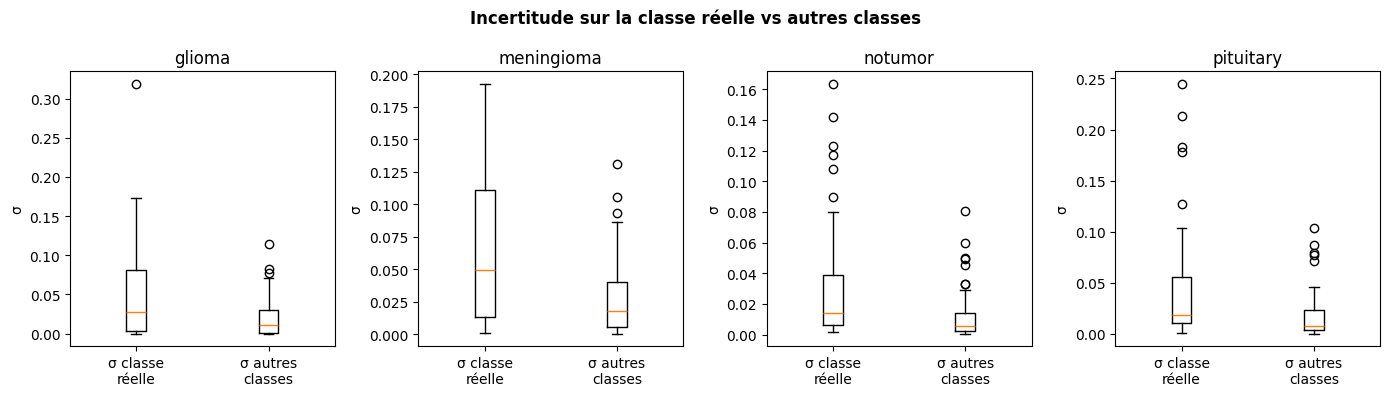

In [53]:
N_PER_CLASS = 50
CLIN_MED = np.array([[0.5]], dtype=np.float32)

results_outside = {cls: {"sigma_inside": [], "sigma_outside": []} for cls in CLASSES}

model_bnn.eval()
for cls in CLASSES:
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    sampled = random.sample(paths, min(N_PER_CLASS, len(paths)))
    true_idx = CLASSES.index(cls)

    for p in sampled:
        img_t  = load_image(p)
        with torch.no_grad():
            passes = torch.stack([
                torch.softmax(model_bnn(img_t), dim=1)
                for _ in range(MC_PASSES)
            ])
        std_p = passes.std(0).cpu().numpy()[0]
        results_outside[cls]["sigma_inside"].append(std_p[true_idx])
        # moyenne de sigma sur toutes les classes sauf la vraie
        results_outside[cls]["sigma_outside"].append(std_p[[i for i in range(4) if i != true_idx]].mean())

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cls in zip(axes, CLASSES):
    inside  = results_outside[cls]["sigma_inside"]
    outside = results_outside[cls]["sigma_outside"]
    ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
    ax.set_title(cls)
    ax.set_ylabel("σ")
plt.suptitle("Incertitude sur la classe réelle vs autres classes", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_inside_vs_outside.png", dpi=150)
plt.show()

glioma terminé
meningioma terminé
notumor terminé
pituitary terminé


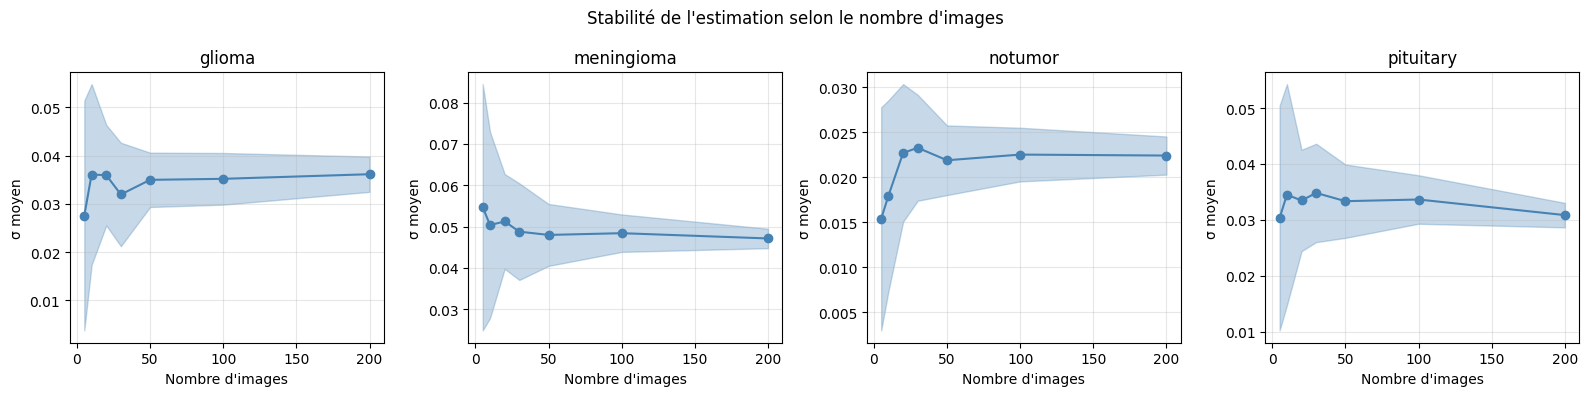


glioma:
  n=  5 → σ moyen = 0.0276 ± 0.0238
  n= 10 → σ moyen = 0.0361 ± 0.0187
  n= 20 → σ moyen = 0.0359 ± 0.0104
  n= 30 → σ moyen = 0.0319 ± 0.0107
  n= 50 → σ moyen = 0.0350 ± 0.0056
  n=100 → σ moyen = 0.0352 ± 0.0053
  n=200 → σ moyen = 0.0361 ± 0.0037

meningioma:
  n=  5 → σ moyen = 0.0547 ± 0.0298
  n= 10 → σ moyen = 0.0504 ± 0.0225
  n= 20 → σ moyen = 0.0512 ± 0.0115
  n= 30 → σ moyen = 0.0488 ± 0.0117
  n= 50 → σ moyen = 0.0480 ± 0.0075
  n=100 → σ moyen = 0.0484 ± 0.0045
  n=200 → σ moyen = 0.0471 ± 0.0024

notumor:
  n=  5 → σ moyen = 0.0154 ± 0.0124
  n= 10 → σ moyen = 0.0180 ± 0.0106
  n= 20 → σ moyen = 0.0227 ± 0.0076
  n= 30 → σ moyen = 0.0233 ± 0.0059
  n= 50 → σ moyen = 0.0219 ± 0.0039
  n=100 → σ moyen = 0.0225 ± 0.0030
  n=200 → σ moyen = 0.0224 ± 0.0021

pituitary:
  n=  5 → σ moyen = 0.0303 ± 0.0201
  n= 10 → σ moyen = 0.0345 ± 0.0198
  n= 20 → σ moyen = 0.0335 ± 0.0091
  n= 30 → σ moyen = 0.0348 ± 0.0088
  n= 50 → σ moyen = 0.0333 ± 0.0066
  n=100 → σ moyen = 

In [54]:
N_SIZES = [5, 10, 20, 30, 50, 100, 200]
N_PASSES_STABILITY = 10
N_BOOTSTRAP = 20

all_paths_by_class = {}
for cls in CLASSES:
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    all_paths_by_class[cls] = paths

results = {cls: {n: [] for n in N_SIZES} for cls in CLASSES}

model_bnn.eval()
for cls in CLASSES:
    paths = all_paths_by_class[cls]
    for n in N_SIZES:
        for _ in range(N_BOOTSTRAP):
            sampled = random.sample(paths, min(n, len(paths)))
            sigmas = []
            for p in sampled:
                img_t = load_image(p)
                with torch.no_grad():
                    passes = torch.stack([
                        torch.softmax(model_bnn(img_t), dim=1)
                        for _ in range(N_PASSES_STABILITY)
                    ])
                std_p = passes.std(0).cpu().numpy()[0]
                sigmas.append(std_p[CLASSES.index(cls)])
            results[cls][n].append(np.mean(sigmas))
    print(f"{cls} terminé")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    means = [np.mean(results[cls][n]) for n in N_SIZES]
    stds  = [np.std(results[cls][n]) for n in N_SIZES]
    ax.plot(N_SIZES, means, "o-", color="steelblue")
    ax.fill_between(N_SIZES,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.3, color="steelblue")
    ax.set_xlabel("Nombre d'images")
    ax.set_ylabel("σ moyen")
    ax.set_title(cls)
    ax.grid(True, alpha=0.3)

plt.suptitle("Stabilité de l'estimation selon le nombre d'images", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stability_n_images.png", dpi=150)
plt.show()

for cls in CLASSES:
    print(f"\n{cls}:")
    for n in N_SIZES:
        m = np.mean(results[cls][n])
        s = np.std(results[cls][n])
        print(f"  n={n:3d} → σ moyen = {m:.4f} ± {s:.4f}")